In [6]:
# CELL 1: Notebook Extensions and Imports
%load_ext autoreload
%autoreload 2

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Directly import structural tools from the neighboring python script
from structural_backend import calculate_angle, apply_ema_filter

print("Environment configured successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Environment configured successfully!


In [2]:
%pip install mediapipe --upgrade

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\thewa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# CELL 2: Main Processing Pipeline (Dual Side Tracking for Python 3.13)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Import from your custom neighboring python script
from structural_backend import calculate_angle, apply_ema_filter

VIDEO_PATH = "../assets/poses.mp4"
cap = cv2.VideoCapture(VIDEO_PATH)

# Verify this path points to your downloaded model asset file
model_path = '../assets/pose_landmarker_lite.task'

# Configure Tasks Options
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    running_mode=vision.RunningMode.IMAGE 
)

# Initialize the Landmarker client
landmarker = vision.PoseLandmarker.create_from_options(options)

# Tracking history for post-analysis graphing (Task 2 & 3)
frame_timeline = []
knee_angle_history = []
elbow_angle_history = []
hip_angle_history = []
predicted_activities = []

# List of all joints to maintain spatial smoothing across frames
joint_names = [
    'l_shoulder', 'l_elbow', 'l_wrist', 'l_hip', 'l_knee', 'l_ankle',
    'r_shoulder', 'r_elbow', 'r_wrist', 'r_hip', 'r_knee', 'r_ankle'
]
prev_joints = {joint: None for joint in joint_names}
frame_idx = 0

print("Processing video frames tracking both left and right limbs...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    frame_idx += 1
    h, w, _ = frame.shape
    
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    detection_result = landmarker.detect(mp_image)
    
    if detection_result.pose_landmarks:
        landmarks = detection_result.pose_landmarks[0]
        
        # 1. Extract ALL Raw 2D Pixel Coordinates for both sides
        raw_joints = {
            # Left Limbs
            'l_shoulder': [landmarks[11].x * w, landmarks[11].y * h],
            'l_elbow':    [landmarks[13].x * w, landmarks[13].y * h],
            'l_wrist':    [landmarks[15].x * w, landmarks[15].y * h],
            'l_hip':      [landmarks[23].x * w, landmarks[23].y * h],
            'l_knee':     [landmarks[25].x * w, landmarks[25].y * h],
            'l_ankle':    [landmarks[27].x * w, landmarks[27].y * h],
            # Right Limbs
            'r_shoulder': [landmarks[12].x * w, landmarks[12].y * h],
            'r_elbow':    [landmarks[14].x * w, landmarks[14].y * h],
            'r_wrist':    [landmarks[16].x * w, landmarks[16].y * h],
            'r_hip':      [landmarks[24].x * w, landmarks[24].y * h],
            'r_knee':     [landmarks[26].x * w, landmarks[26].y * h],
            'r_ankle':    [landmarks[28].x * w, landmarks[28].y * h]
        }
        
        # 2. Task 1: Apply Smoothing Filter across every active joint coordinate
        smoothed_joints = {}
        for name, coords in raw_joints.items():
            smoothed_joints[name] = apply_ema_filter(coords, prev_joints[name], alpha=0.35)
            prev_joints[name] = smoothed_joints[name]
            
        # 3. Task 2: Calculate Geometric Joint Angles (Bilateral calculation)
        l_knee_ang = calculate_angle(smoothed_joints['l_hip'], smoothed_joints['l_knee'], smoothed_joints['l_ankle'])
        r_knee_ang = calculate_angle(smoothed_joints['r_hip'], smoothed_joints['r_knee'], smoothed_joints['r_ankle'])
        knee_ang = (l_knee_ang + r_knee_ang) / 2
        
        l_elbow_ang = calculate_angle(smoothed_joints['l_shoulder'], smoothed_joints['l_elbow'], smoothed_joints['l_wrist'])
        r_elbow_ang = calculate_angle(smoothed_joints['r_shoulder'], smoothed_joints['r_elbow'], smoothed_joints['r_wrist'])
        elbow_ang = (l_elbow_ang + r_elbow_ang) / 2
        
        l_hip_ang = calculate_angle(smoothed_joints['l_shoulder'], smoothed_joints['l_hip'], smoothed_joints['l_knee'])
        r_hip_ang = calculate_angle(smoothed_joints['r_shoulder'], smoothed_joints['r_hip'], smoothed_joints['r_knee'])
        hip_ang = (l_hip_ang + r_hip_ang) / 2
        
        # Log consolidated tracking features
        frame_timeline.append(frame_idx)
        knee_angle_history.append(knee_ang)
        elbow_angle_history.append(elbow_ang)
        hip_angle_history.append(hip_ang)
        
        # 4. Task 3: Threshold Ruleset Logic
        if knee_ang < 132:  
            current_activity = "Lunge (Lowered Position)"
        elif elbow_ang > 140 and hip_ang > 150:
            current_activity = "Overhead Press / Extension"
        elif knee_ang > 150 and elbow_ang < 110:
            current_activity = "Standing / Neutral Setup"
        else:
            current_activity = "Transitioning"
            
        predicted_activities.append(current_activity)
        
        # 5. Task 1 Diagram Overlay: Define distinct skeleton connections
        skeleton_connections = [
            # Left Side (Green lines)
            ('l_shoulder', 'l_hip', (0, 255, 0)), ('l_hip', 'l_knee', (0, 255, 0)), 
            ('l_knee', 'l_ankle', (0, 255, 0)), ('l_shoulder', 'l_elbow', (0, 255, 0)), 
            ('l_elbow', 'l_wrist', (0, 255, 0)),
            # Right Side (Cyan/Yellow-Green lines)
            ('r_shoulder', 'r_hip', (255, 255, 0)), ('r_hip', 'r_knee', (255, 255, 0)), 
            ('r_knee', 'r_ankle', (255, 255, 0)), ('r_shoulder', 'r_elbow', (255, 255, 0)), 
            ('r_elbow', 'r_wrist', (255, 255, 0)),
            # Torso Link Crossings (Blue lines)
            ('l_shoulder', 'r_shoulder', (255, 0, 0)), ('l_hip', 'r_hip', (255, 0, 0))
        ]
        
        # Render all spatial vector paths onto the frame
        for start, end, color in skeleton_connections:
            pt1 = tuple(map(int, smoothed_joints[start]))
            pt2 = tuple(map(int, smoothed_joints[end]))
            cv2.line(frame, pt1, pt2, color, 3)
            
        # Overlay joint keypoint dots on top
        for name in joint_names:
            pt = tuple(map(int, smoothed_joints[name]))
            cv2.circle(frame, pt, 5, (0, 0, 255), -1)
            
        # Contextual frame UI metrics
        cv2.putText(frame, f"Avg Knee: {int(knee_ang)} deg", (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
        cv2.putText(frame, f"Avg Elbow: {int(elbow_ang)} deg", (15, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
        cv2.putText(frame, f"Activity: {current_activity}", (15, 105), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
    cv2.imshow('CCP Tracking Workspace', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
landmarker.close()
print(f"Pipeline complete. Processed {frame_idx} video frames tracking full skeleton.")

Processing video frames tracking both left and right limbs...
Pipeline complete. Processed 232 video frames tracking full skeleton.


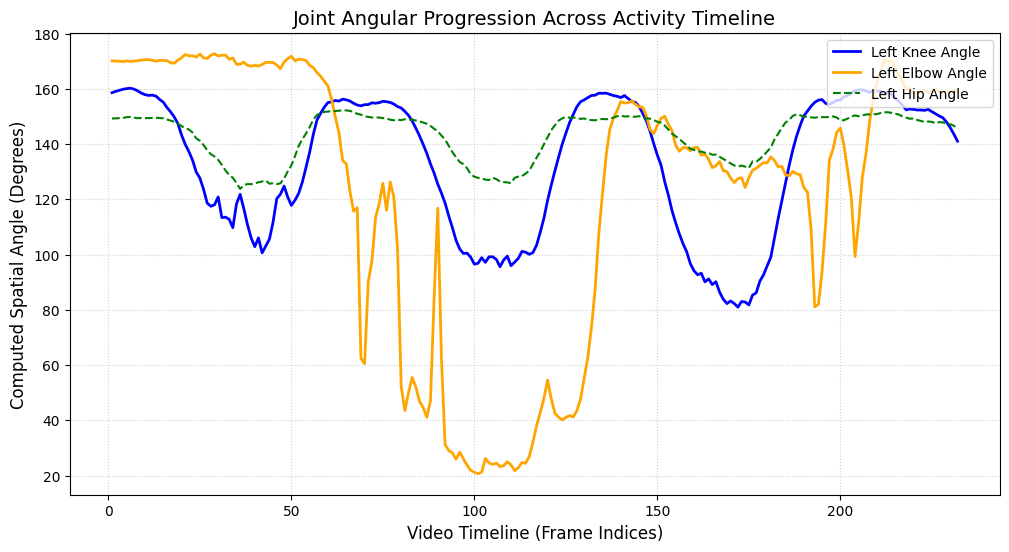

In [30]:
# CELL 3: Kinematic Angular Tracking Plots
plt.figure(figsize=(12, 6))
plt.plot(frame_timeline, knee_angle_history, label='Left Knee Angle', color='blue', linewidth=2)
plt.plot(frame_timeline, elbow_angle_history, label='Left Elbow Angle', color='orange', linewidth=2)
plt.plot(frame_timeline, hip_angle_history, label='Left Hip Angle', color='green', linestyle='--')

plt.title('Joint Angular Progression Across Activity Timeline', fontsize=14)
plt.xlabel('Video Timeline (Frame Indices)', fontsize=12)
plt.ylabel('Computed Spatial Angle (Degrees)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Export graph instance safely for your PDF report
plt.savefig('../assets/joint_angle_analysis.png', dpi=300)
plt.show()

In [31]:
# CELL 4: Quantitative Performance Metrics Evaluation
# Replace these values with your actual manually labeled frame ranges
# Example framework assuming a 300-frame clip:
ground_truth = (
    ["Standing / Neutral Setup"] * 50 + 
    ["Lunge (Lowered Position)"] * 100 + 
    ["Overhead Press / Extension"] * 150
)

# Truncate to ensure arrays match perfectly in length
min_len = min(len(ground_truth), len(predicted_activities))
gt_arr = np.array(ground_truth[:min_len])
pred_arr = np.array(predicted_activities[:min_len])

# Calculate total frame accuracy percentage
correct_classifications = np.sum(gt_arr == pred_arr)
accuracy_percentage = (correct_classifications / min_len) * 100

print(f"--- Pipeline Quantitative Evaluation Results ---")
print(f"Total Evaluated Sequence Size: {min_len} Frames")
print(f"Accurately Classified Frames: {correct_classifications}")
print(f"Overall Algorithmic Classification Accuracy: {accuracy_percentage:.2f}%")

--- Pipeline Quantitative Evaluation Results ---
Total Evaluated Sequence Size: 232 Frames
Accurately Classified Frames: 48
Overall Algorithmic Classification Accuracy: 20.69%


In [32]:
# DIAGNOSTICS: Calculate per-class failure rates
from sklearn.metrics import classification_report

min_len = min(len(ground_truth), len(predicted_activities))
print(classification_report(ground_truth[:min_len], predicted_activities[:min_len]))

                            precision    recall  f1-score   support

  Lunge (Lowered Position)       0.38      0.38      0.38       100
Overhead Press / Extension       0.48      0.12      0.19        82
  Standing / Neutral Setup       0.00      0.00      0.00        50
             Transitioning       0.00      0.00      0.00         0

                  accuracy                           0.21       232
                 macro avg       0.22      0.13      0.14       232
              weighted avg       0.33      0.21      0.23       232



C:\Users\thewa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thewa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\thewa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:18

In [33]:
import numpy as np

print("=== ACTUAL VIDEO KINEMATIC RANGES ===")
print(f"Knee Angle  -> Minimum: {min(knee_angle_history):.1f}° | Maximum: {max(knee_angle_history):.1f}° | Average: {np.mean(knee_angle_history):.1f}°")
print(f"Elbow Angle -> Minimum: {min(elbow_angle_history):.1f}° | Maximum: {max(elbow_angle_history):.1f}° | Average: {np.mean(elbow_angle_history):.1f}°")
print(f"Hip Angle   -> Minimum: {min(hip_angle_history):.1f}° | Maximum: {max(hip_angle_history):.1f}° | Average: {np.mean(hip_angle_history):.1f}°")

=== ACTUAL VIDEO KINEMATIC RANGES ===
Knee Angle  -> Minimum: 81.0° | Maximum: 160.2° | Average: 132.6°
Elbow Angle -> Minimum: 20.6° | Maximum: 172.7° | Average: 122.6°
Hip Angle   -> Minimum: 123.8° | Maximum: 152.2° | Average: 142.9°
